# 4x3 Grid World: Monte Carlo Methods

This notebook applies simple MC methods to the 4x3 Grid World with non-deterministic actions.

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define the $4 \times 3$ Grid World

The used example is the simple $4 \times 3$ grid world described in AIMA Chapter 17.

![4x3 grid world description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/AIMA_Figure_17_1.png)

AIMA Figure 17.1: (a) A simple, stochastic 
 environment that presents the agent with a sequential decision problem. (b) Illustration of the transition model of the environment: the “intended” outcome occurs with probability 0.8, but with probability 0.2 the agent moves at right angles to the intended direction. A collision with a wall results in no movement. Transitions into the two terminal states have reward +1 and -1, respectively, and all other transitions have a reward of -0.04.

The patched `gym-classic` already defined this environment.

In [3]:
gym_env = gym.make('ClassicGridworld-v1')
env = gym_env.unwrapped

Show the state layout. Unreachable states are not stored and shown as -1.

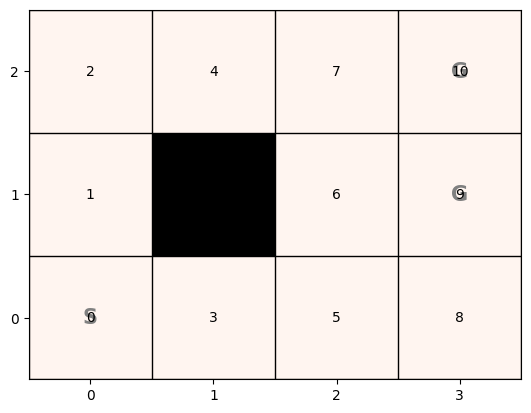

In [4]:
env.image()

## Monte Carlo Prediction

Estimate the value function for a policy using sample trajectories. This is also called policy evaluation. 

We already know that we can use sampling
many trajectories from a state to estimate the state value using the average return. The idea here is that the estimate for each state in the episode can be updated with the
return over the rest of the episode.  

![Monte Carlo Prediciton](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_MC_Prediction.png)

In [5]:
manual_pol = [env.encode_action("up")] * len(env.states())
manual_pol[2] = env.encode_action("right")
manual_pol[4] = env.encode_action("right")
manual_pol[7] = env.encode_action("right")

manual_pol

[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0]

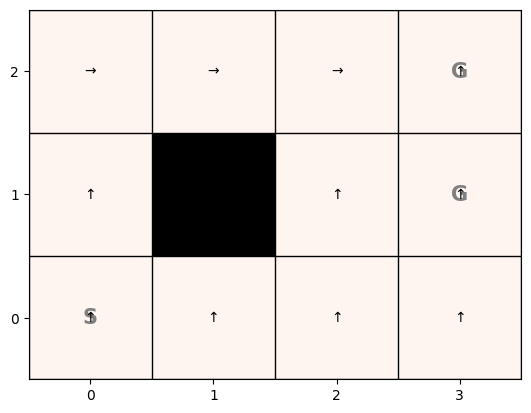

In [6]:
env.image(policy = manual_pol)

Sample complete episodes. The starting (s,a) can be specified (used for exploring starts).

In [ ]:
def sample_episode(env, policy, start_state = None, start_action = None, max_len = 1000):
 
    episode = []
    
    s, r = env.reset()
    
    # set starting state
    if not start_state is None:
        s = start_state
        env.state = env.decode(s)
    
    step = 0
    done = False
    while not done and step < max_len:
        a = policy[s]
        
        # override policy for the starting action
        if step == 0 and not start_action is None:
            a = start_action
        
        sp, reward, done, _, _ = env.step(a)
        episode.append((s,a,reward,sp))
        
        s = sp
        step += 1
        
    return(episode)

[(0, 0, -0.04, 1),
 (1, 0, -0.04, 2),
 (2, 1, -0.04, 4),
 (4, 1, -0.04, 4),
 (4, 1, -0.04, 7),
 (7, 1, -0.04, 6),
 (6, 0, -0.04, 7),
 (7, 1, -0.04, 6),
 (6, 0, -0.04, 7),
 (7, 1, 1.0, 10)]

In [9]:
 
sample_episode(env, manual_pol)


[(0, 0, -0.04, 1),
 (1, 0, -0.04, 2),
 (2, 1, -0.04, 4),
 (4, 1, -0.04, 7),
 (7, 1, 1.0, 10)]

Now we can implement MC prediction.

In [13]:
def MC_prediction(env, policy, discount, n = 100):
    #V = np.zeros(len(env.states()))
    # we will create the array later
    
    Returns = [[] for _ in env.states()]
    
    for i in range(n):
        episode = sample_episode(env, policy)
        G = 0
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit only
            if not s in [step[0] for step in episode][0:t]:
                Returns[s].append(G)
                  
    # calculate all state value (np.mean unnecessarily throws a warning for empty lists)
    V = np.array([np.mean(G) if len(G) else np.nan for G in Returns])
    return V  

In [22]:
V_MC = MC_prediction(env, manual_pol, discount=1, n=100)
V_MC

array([0.7 , 0.79, 0.83, 0.47, 0.89, 0.59, 0.57, 0.95,  nan,  nan,  nan])

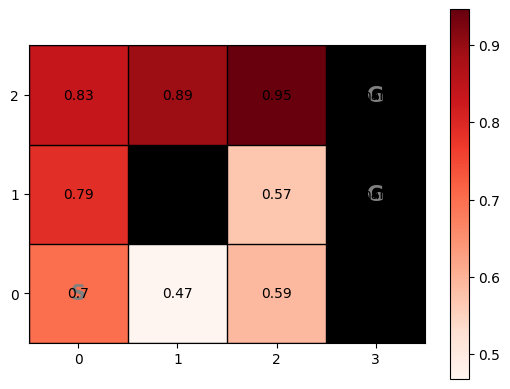

In [23]:
env.image(V_MC, labels = True)

Note: `nan` means that the state does not exist or was never visited. We would need more exploration (e.g., using exploring starts to fix this)! 

## Monte Carlo Control

Goal: Find the optimal policy using MC.

Issue: Many $(s,a)$-pairs will never be visited when following $\pi$. We need to keep exploring! 

Options:
* Exploring starts: choose the starting $(s,a)$ for each episode randomly.
* Only consider soft policies like $\epsilon$-greedy. Soft policies have non-zero probabilities for all actions.


### On-policy MC Control with Exploring Starts

Start episodes randomly from all possible $(a,s)$ pairs.

![MC Control with ES](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_MC_Control_ES.png)

In [24]:
from collections import defaultdict
from gym_classics.algorithms.policy import random_policy

# np.argmax does not break ties randomly so we define a version that does.
def random_argmax(x):
        return np.random.choice(np.where(x == np.max(x))[0])
        

def MC_control_ES(env, discount, n = 100, max_episode_len = 100): 
    policy = random_policy(env)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    Returns = defaultdict(list) # a list for each (s,a)

    
    for i in range(n):
        # Sample starting (s,a)
        s = np.random.choice(env.states())
        a = np.random.choice(env.actions())
        
        episode = sample_episode(env, policy, start_state = s, start_action = a, max_len=max_episode_len)
        G = 0
        
        # for first visit check for (s,a)
        visited = [(s,a) for s,a,r,sp in episode]
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit of (s,a) only
            if not (s,a) in visited[0:t]:
                Returns[(s,a)].append(G)
            
                # update policy
                Q[s,a] = np.mean(Returns[(s,a)])
                policy[s] = random_argmax(Q[s,:])
          
    return policy, Q

In [29]:
pol, Q = MC_control_ES(env, discount=1, n=1000)
pol


array([0, 0, 1, 1, 1, 0, 0, 1, 3, 3, 3])

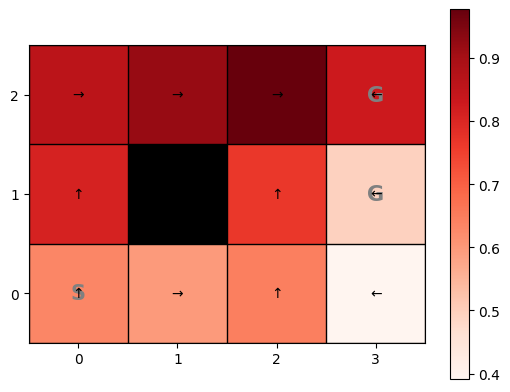

In [30]:

env.image(V = np.max(Q, axis = 1), policy = pol)


**Note:** Goal states are absorbing so actions in the goal states are artifacts and do no matter.

The algorithm also estimates a Q-function with the action values for each state.

In [31]:
Q

array([[ 0.63,  0.57,  0.41,  0.34],
       [ 0.81,  0.48,  0.49,  0.54],
       [ 0.63,  0.86,  0.49,  0.51],
       [ 0.26,  0.6 ,  0.4 ,  0.24],
       [ 0.91,  0.92,  0.81,  0.58],
       [ 0.64,  0.36,  0.26,  0.27],
       [ 0.76, -0.78,  0.45,  0.67],
       [ 0.92,  0.98,  0.65,  0.81],
       [-0.73, -0.22, -0.31,  0.39],
       [ 0.  , -0.05,  0.26,  0.49],
       [ 0.28,  0.  ,  0.04,  0.83]])

Let's look at one episode following the policy. This will show a typical path taken.

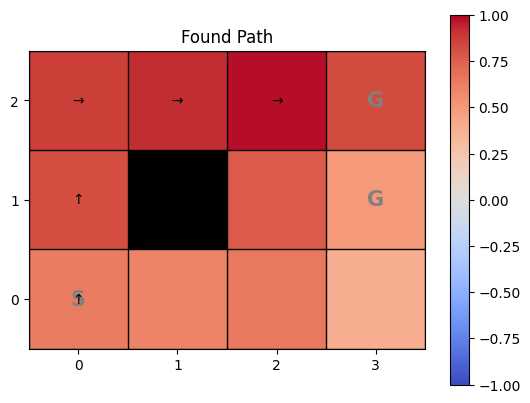

In [32]:
path = sample_episode(env, policy=pol, max_len=100)
env.image(V=np.max(Q, axis = 1), policy=pol, episode=path, title='Found Path', clim=(-1,1))

### Learning Progress 

To track progress, we save each episode's return.

In [33]:
def MC_control_ES_progress(env, discount, n = 100, max_episode_len = 100): 
    Returns = defaultdict(list) # a list for each (s,a)
    policy = random_policy(env)
    episode_returns = []
    
    for i in range(n):
        # Sample starting (s,a)
        s = np.random.choice(env.states())
        a = np.random.choice(env.actions())
        
        episode = sample_episode(env, policy, start_state = s, start_action = a, max_len=max_episode_len)
        G = 0
        
        # for first visit check for (s,a)
        visited = [(s,a) for s,a,r,sp in episode]
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit of (s,a) only
            if not (s,a) in visited[0:t]:
                Returns[(s,a)].append(G)
            
                # update policy
                Q[s,a] = np.mean(Returns[(s,a)])
                policy[s] = random_argmax(Q[s,:])
        
        episode_returns.append(G)
          
    return policy, Q, episode_returns

In [34]:
pol, Q, episode_returns = MC_control_ES_progress(env, discount=1, n = 10000)

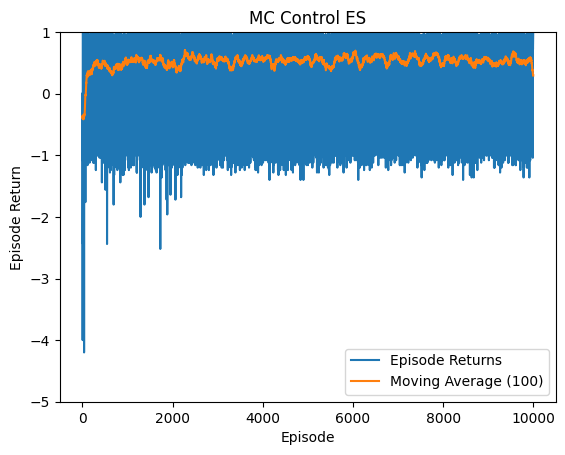

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def simple_moving_average(data, window_size):
    # Define uniform weights for the moving average window
    weights = np.ones(window_size) / window_size
    # Use convolution with 'valid' mode to return only the fully calculated values
    sma = np.convolve(data, weights, mode='same')
    return sma

x = range(len(episode_returns))
plt.plot(x, episode_returns, label="Episode Returns")
plt.plot(x, simple_moving_average(episode_returns, 100), label="Moving Average (100)")

plt.xlabel("Episode")
plt.ylabel("Episode Return")
plt.ylim(-5,1)
plt.title("MC Control ES")
plt.legend()
plt.show()

Note: Exploring starts is not a real online-RL method because it does not start episodes at the start state. So the rewards we get are for "pieces" of complete episodes; some will be longer and others shorter. Also, if we are unlucky, then the chosen start state/action combination leads us directly into the trap!

### More Algorithms

* On-policy MC control with $\epsilon$-soft policy
* Off-policy MC prediction and control using importance sampling.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)